In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#Get List of CSVs
files = os.listdir("/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/")
#Filter out non-csv files, folders or csv that don't start with a digit
import re
filtered = [f for f in files if re.match(r'^\d', f) and f.endswith('.csv')]
print(len(filtered))

pairs = [re.match(r'^(\d+-\d+)', f).group(1) for f in filtered]
print(pairs)

77
['6-6', '8-7', '8-6', '9-1', '10-1', '6-8', '8-8', '10-7', '3-5', '5-1', '5-5', '7-1', '2-7', '10-6', '4-7', '7-7', '7-6', '4-5', '9-2', '10-4', '3-1', '9-7', '8-1', '10-8', '8-4', '4-6', '4-4', '3-8', '5-4', '9-6', '10-5', '7-8', '5-2', '9-8', '1-2', '5-6', '10-2', '2-6', '6-1', '2-4', '1-4', '4-1', '1-6', '6-2', '8-5', '5-7', '1-5', '1-8', '5-3', '6-5', '9-5', '4-8', '7-2', '2-5', '7-3', '9-3', '9-4', '8-2', '10-3', '6-3', '3-2', '7-5', '3-7', '2-3', '1-3', '8-3', '2-8', '7-4', '4-2', '6-4', '1-1', '3-3', '4-3', '3-4', '2-2', '1-7', '3-6']


In [2]:
cycle_lengths = []
cycle_lengths_sort = {}
#Correlation of k, a and b with cycle number
##Place k, a and b of all cells in all cycles in one dataframe
for choice in pairs:
    gompertz_df_full = pd.read_csv("/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/" + choice + "-hust_gompertz_params.csv")
    cycle_lengths.append(gompertz_df_full.shape[0])
    cycle_lengths_sort[choice] = gompertz_df_full.shape[0]
print(f"Max : {max(cycle_lengths)}, Min : {min(cycle_lengths)}")


#sort pairs by RUL
pairs = sorted(cycle_lengths_sort, key=cycle_lengths_sort.get)
print(pairs)

Max : 2689, Min : 1142
['4-3', '1-6', '7-3', '8-1', '8-5', '4-6', '2-5', '7-4', '10-8', '7-6', '5-7', '2-8', '4-4', '2-4', '1-4', '1-1', '4-5', '2-6', '5-5', '6-1', '3-3', '1-7', '8-8', '7-7', '7-1', '10-2', '10-1', '4-8', '6-4', '9-6', '2-3', '3-4', '4-2', '10-7', '6-3', '10-4', '10-3', '1-3', '7-5', '8-4', '9-3', '6-2', '5-2', '3-1', '7-8', '5-4', '1-5', '9-4', '9-7', '10-5', '7-2', '8-2', '8-7', '9-1', '9-2', '9-5', '6-5', '2-7', '4-7', '4-1', '3-2', '10-6', '1-8', '8-3', '9-8', '3-8', '8-6', '6-8', '5-6', '6-6', '3-7', '3-6', '5-1', '2-2', '3-5', '1-2', '5-3']


Processing Cell :  4-3
Processing Cell :  1-6
Processing Cell :  7-3
Processing Cell :  8-1
Processing Cell :  8-5
Processing Cell :  4-6
Processing Cell :  2-5
Processing Cell :  7-4
Processing Cell :  10-8
Processing Cell :  7-6
Processing Cell :  5-7
Processing Cell :  2-8
Processing Cell :  4-4
Processing Cell :  2-4
Processing Cell :  1-4
Processing Cell :  1-1
Processing Cell :  4-5
Processing Cell :  2-6
Processing Cell :  5-5
Processing Cell :  6-1
Processing Cell :  3-3
Processing Cell :  1-7
Processing Cell :  8-8
Processing Cell :  7-7
Processing Cell :  7-1
Processing Cell :  10-2
Processing Cell :  10-1
Processing Cell :  4-8
Processing Cell :  6-4
Processing Cell :  9-6
Processing Cell :  2-3
Processing Cell :  3-4
Processing Cell :  4-2
Processing Cell :  10-7
Processing Cell :  6-3
Processing Cell :  10-4
Processing Cell :  10-3
Processing Cell :  1-3
Processing Cell :  7-5
Processing Cell :  8-4
Processing Cell :  9-3
Processing Cell :  6-2
Processing Cell :  5-2
Proce

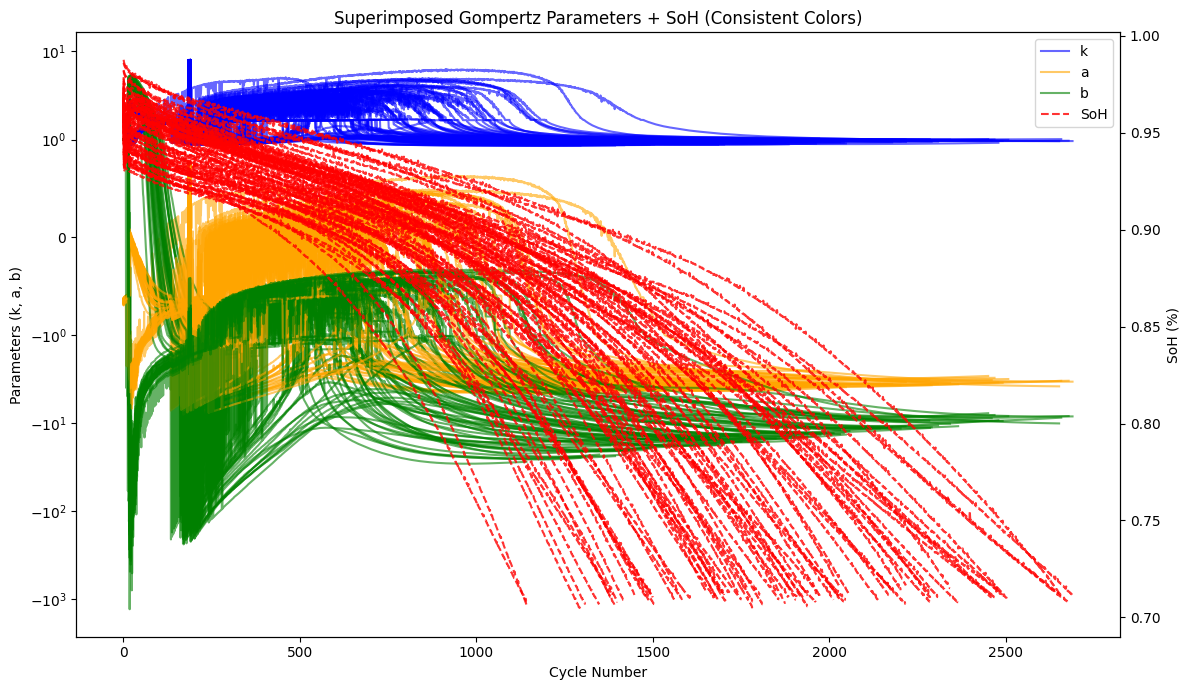

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 7))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Define a fixed color map for consistency
color_map = {
    "k": "blue",
    "a": "orange",
    "b": "green",
    "SoH": "red"
}

for choice in pairs:
    if choice == '1-8':
        continue
    print('Processing Cell : ', choice)
    # Ensure your path matches your local environment
    gompertz_df_full = pd.read_csv(f"/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/{choice}-hust_gompertz_params.csv")
    
    x = gompertz_df_full["Cycle number"]
    
    # --- Plot Parameters (k, a, b) on Left Axis ---
    for col in ["k", "a", "b"]:
        ax1.plot(x, gompertz_df_full[col], color=color_map[col], alpha=0.6, label=col if choice == pairs[0] else "")
    
    # --- Plot SoH on Right Axis ---
    ax2.plot(x, gompertz_df_full["SoH"], color=color_map["SoH"], linestyle='--', alpha=0.8, label="SoH" if choice == pairs[0] else "")

# Formatting
ax1.set_xlabel("Cycle Number")
ax1.set_ylabel("Parameters (k, a, b)")
ax1.set_yscale('symlog', linthresh=1)
ax2.set_ylabel("SoH (%)")
plt.title("Superimposed Gompertz Parameters + SoH (Consistent Colors)")

# --- Clean Legend ---
# This logic ensures we only get one entry per type instead of repeating for every cell
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.savefig("HUST-All-Cells-Consistent-Colors.png", dpi=300)
plt.show()

Processing Cell :  4-3
Processing Cell :  1-6
Processing Cell :  7-3
Processing Cell :  8-1
Processing Cell :  8-5
Processing Cell :  4-6
Processing Cell :  2-5
Processing Cell :  7-4
Processing Cell :  10-8
Processing Cell :  7-6
Processing Cell :  5-7
Processing Cell :  2-8
Processing Cell :  4-4
Processing Cell :  2-4
Processing Cell :  1-4
Processing Cell :  1-1
Processing Cell :  4-5
Processing Cell :  2-6
Processing Cell :  5-5
Processing Cell :  6-1
Processing Cell :  3-3
Processing Cell :  1-7
Processing Cell :  8-8
Processing Cell :  7-7
Processing Cell :  7-1
Processing Cell :  10-2
Processing Cell :  10-1
Processing Cell :  4-8
Processing Cell :  6-4
Processing Cell :  9-6
Processing Cell :  2-3
Processing Cell :  3-4
Processing Cell :  4-2
Processing Cell :  10-7
Processing Cell :  6-3
Processing Cell :  10-4
Processing Cell :  10-3
Processing Cell :  1-3
Processing Cell :  7-5
Processing Cell :  8-4
Processing Cell :  9-3
Processing Cell :  6-2
Processing Cell :  5-2
Proce

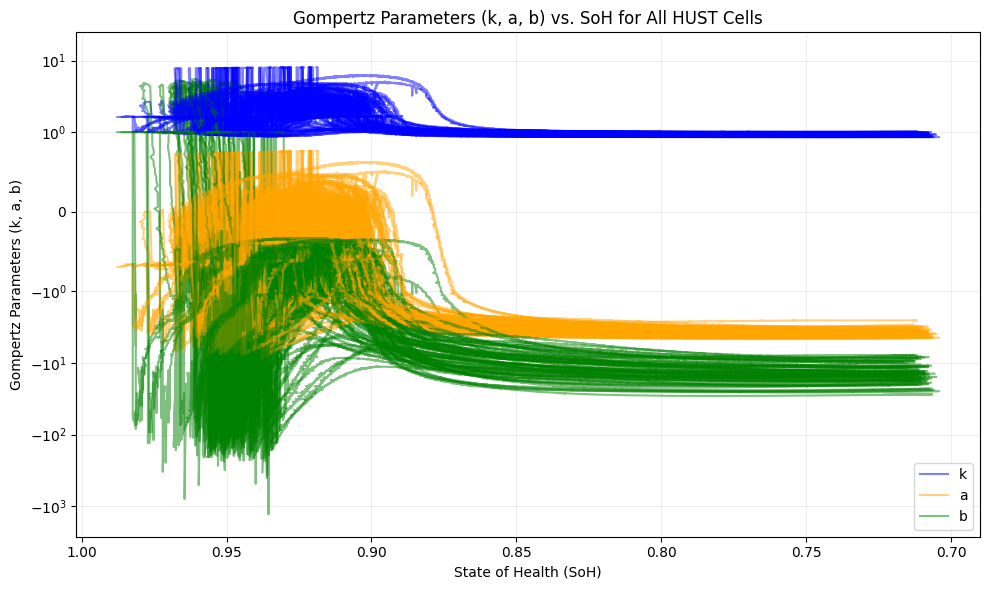

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize the figure
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Define fixed colors for the parameters
color_map = {
    "k": "blue",
    "a": "orange",
    "b": "green"
}

# 2. Iterate through your pairs
for i, choice in enumerate(pairs):
    if choice == '1-8':
        continue
    print('Processing Cell : ', choice)
    # Load data
    gompertz_df_full = pd.read_csv(f"/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/{choice}-hust_gompertz_params.csv")
    
    # New X-axis is SoH
    x = gompertz_df_full["SoH"]
    
    # --- Plot k, a, and b against SoH ---
    for col in ["k", "a", "b"]:
        # We only want one label per parameter type in the legend, 
        # so we only set the label for the first cell processed.
        label_text = col if i == 0 else ""
        
        ax.plot(x, gompertz_df_full[col], 
                color=color_map[col], 
                alpha=0.5, 
                label=label_text)

# 3. Configure axes
ax.set_xlabel("State of Health (SoH)")
ax.set_ylabel("Gompertz Parameters (k, a, b)")
ax.set_yscale('symlog', linthresh=1) # Keeps the scale consistent with your previous plots

# Invert X-axis if you want to see degradation from left (100%) to right (80%)
ax.invert_xaxis() 

plt.title("Gompertz Parameters (k, a, b) vs. SoH for All HUST Cells")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc="lower right")
# --- Fix the Y-axis headroom ---
# Get current limits
ymin, ymax = ax.get_ylim()

# Increase the top limit by 20% to give it breathing room
# Since it's a log scale, multiplying the max works well
ax.set_ylim(ymin, ymax * 1.5) 

# Alternatively, if you know your data bounds (e.g., max is 1000)
# ax.set_ylim(None, 2000) 

plt.tight_layout()
plt.savefig("HUST-Params-vs-SoH.png", dpi=300)
plt.show()

Plotting Tranche: High RUL (>2000) (28 cells)


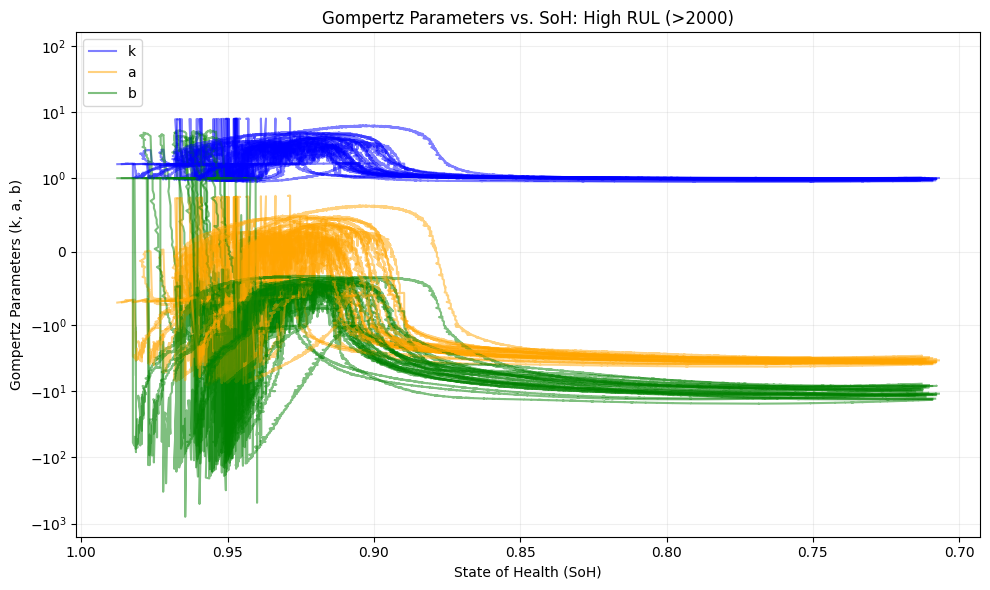

Plotting Tranche: Mid RUL (1500-2000) (35 cells)


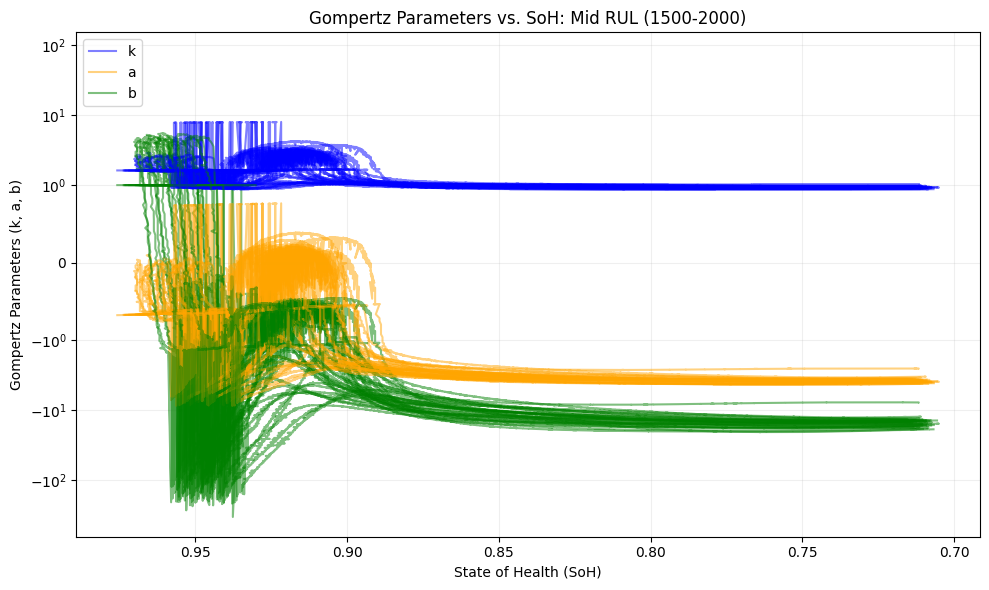

Plotting Tranche: Low RUL (<1500) (13 cells)


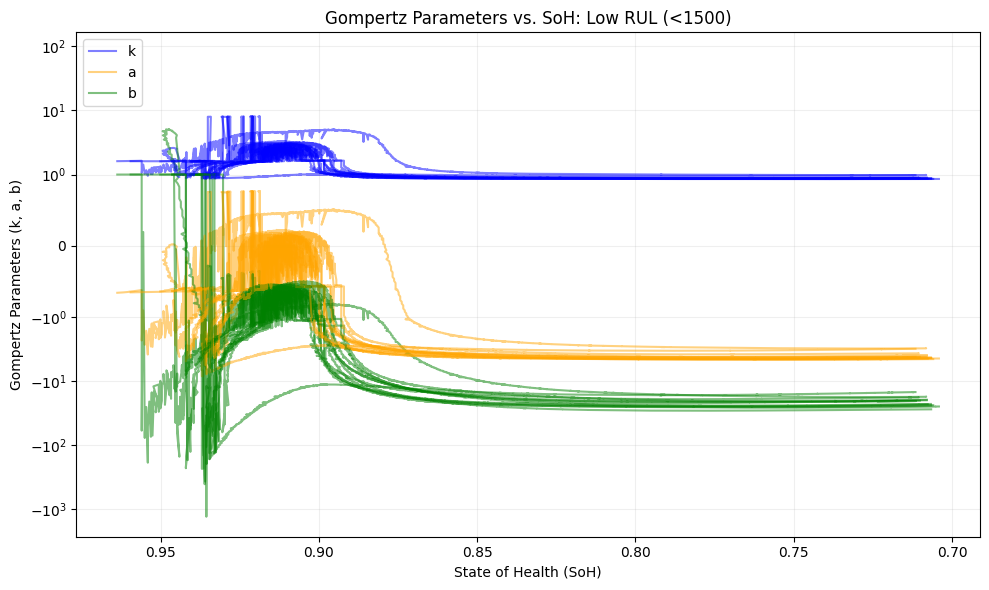

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- 1. Map Cells to Tranches ---
# We'll create a dictionary to store which cell belongs to which tranche
tranche_mapping = {
    'High RUL (>2000)': [],
    'Mid RUL (1500-2000)': [],
    'Low RUL (<1500)': []
}

# Assuming all_files contains the paths to your parameter CSVs
for filename in pairs:
    df = pd.read_csv(f"/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/{filename}-hust_gompertz_params.csv")
    cell_id = filename#os.path.basename(filename).split('-hust')[0]
    
    if cell_id == '1-8': continue # Skip problematic cell
    
    # Calculate total life to determine tranche
    total_life = df['Cycle number'].iloc[0] + df['rul'].iloc[0]
    
    if total_life > 2000: tranche = 'High RUL (>2000)'
    elif total_life >= 1500: tranche = 'Mid RUL (1500-2000)'
    else: tranche = 'Low RUL (<1500)'
    
    tranche_mapping[tranche].append(cell_id)

# --- 2. Generate Separate Plots per Tranche ---
color_map = {"k": "blue", "a": "orange", "b": "green"}

for tranche_name, cells in tranche_mapping.items():
    if not cells: continue # Skip if a tranche is empty
    
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    
    print(f'Plotting Tranche: {tranche_name} ({len(cells)} cells)')
    
    for i, cell_id in enumerate(cells):
        # Load the specific cell data
        file_path = f"/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/{cell_id}-hust_gompertz_params.csv"
        df_cell = pd.read_csv(file_path)
        
        x = df_cell["SoH"]
        
        for col in ["k", "a", "b"]:
            # Only label the first instance of each parameter for the legend
            label_text = col if i == 0 else ""
            ax.plot(x, df_cell[col], color=color_map[col], alpha=0.5, label=label_text)

    # --- Formatting ---
    ax.set_xlabel("State of Health (SoH)")
    ax.set_ylabel("Gompertz Parameters (k, a, b)")
    ax.set_yscale('symlog', linthresh=1)
    ax.invert_xaxis() 
    
    # Dynamic headroom: Symlog needs a significant multiplier to feel "empty"
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 10) 
    
    plt.title(f"Gompertz Parameters vs. SoH: {tranche_name}")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(loc="upper left")
    
    plt.tight_layout()
    # Save with a unique name per tranche
    clean_name = tranche_name.replace(" ", "_").replace(">", "GT").replace("<", "LT")
    plt.savefig(f"HUST-Params-{clean_name}.png", dpi=300)
    plt.show()

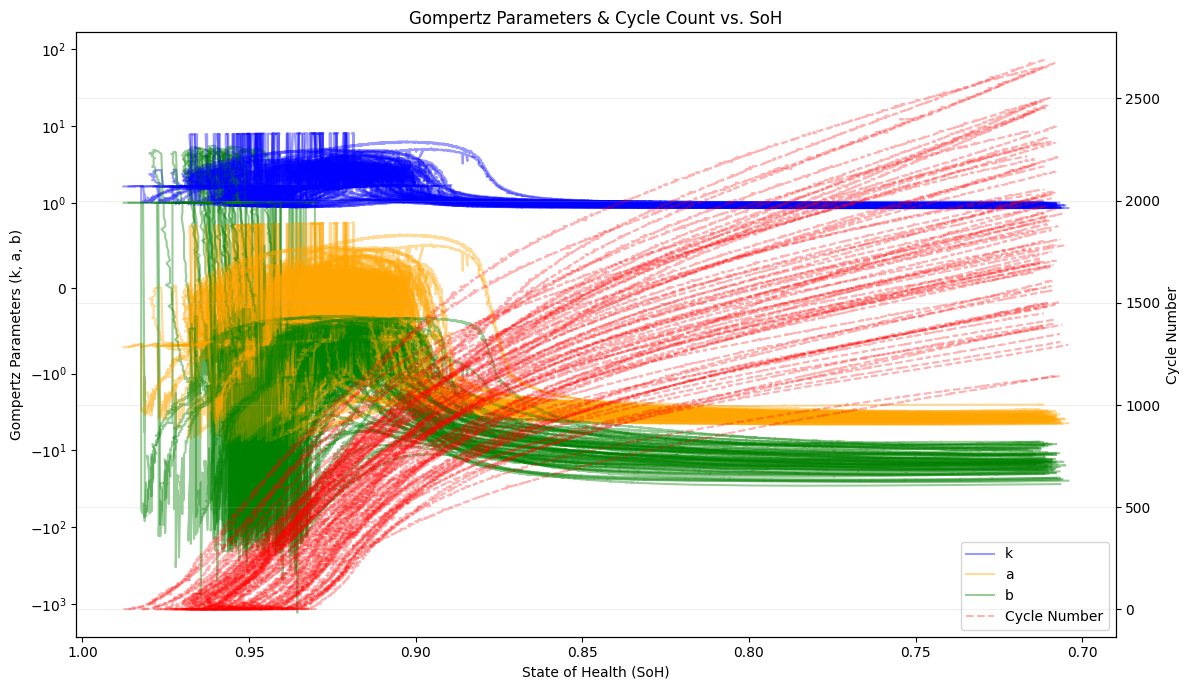

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize the figure
plt.figure(figsize=(12, 7))
ax1 = plt.gca()
ax2 = ax1.twinx() # Secondary axis for Cycle Number

# Define fixed colors
color_map = {
    "k": "blue",
    "a": "orange",
    "b": "green",
    "cycle": "red" # Color for the SoH/Cycle relationship
}

# 2. Iterate through your pairs
for i, choice in enumerate(pairs):
    if choice == '1-8':
        continue
    
    gompertz_df_full = pd.read_csv(f"/kaggle/input/datasets/hypnotu/hust-preprocessed-data/gompertz-parameters-per-cycle/{choice}-hust_gompertz_params.csv")
    
    x = gompertz_df_full["SoH"]
    
    # --- Plot k, a, and b against SoH (Left Axis) ---
    for col in ["k", "a", "b"]:
        label_text = col if i == 0 else ""
        ax1.plot(x, gompertz_df_full[col], 
                color=color_map[col], 
                alpha=0.4, 
                label=label_text)
    
    # --- Plot Cycle Number against SoH (Right Axis) ---
    # This represents the "SoH curve" in this coordinate space
    label_cycle = "Cycle Number" if i == 0 else ""
    ax2.plot(x, gompertz_df_full["Cycle number"], 
             color=color_map["cycle"], 
             linestyle='--', 
             alpha=0.3, 
             label=label_cycle)

# 3. Configure axes
ax1.set_xlabel("State of Health (SoH)")
ax1.set_ylabel("Gompertz Parameters (k, a, b)")
ax1.set_yscale('symlog', linthresh=1)
ax2.set_ylabel("Cycle Number")

# Invert X-axis (100% -> 80%)
ax1.invert_xaxis() 

# 4. Legend Handling
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")

# --- Headroom ---
ymin, ymax = ax1.get_ylim()
ax1.set_ylim(ymin, ymax * 10) 

plt.title("Gompertz Parameters & Cycle Count vs. SoH")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()